In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('credit_card.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [8]:
round(df['isFraud'].value_counts(normalize=True) * 100,2)

isFraud
0    99.87
1     0.13
Name: proportion, dtype: float64

In [9]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [10]:
pd.crosstab(df['isFraud'],df['type'])

type,CASH_IN,CASH_OUT,DEBIT,PAYMENT,TRANSFER
isFraud,,,,,
0,1399284,2233384,41432,2151495,528812
1,0,4116,0,0,4097


In [11]:
pd.crosstab(df['isFlaggedFraud'], df['isFraud'])
#Out of 8,213 frauds, only 16 are flagged.
# That means:It is not leaking the answer

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


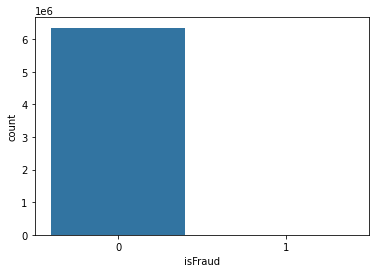

In [12]:
sns.countplot(x='isFraud',data=df)
plt.show()

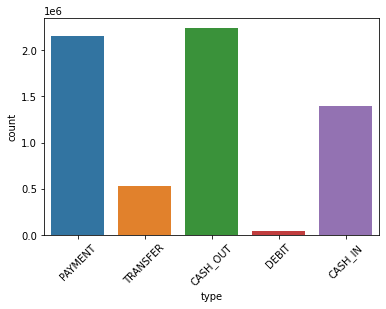

In [13]:
#Transaction Type Distribution

sns.countplot(x='type',data=df)
plt.xticks(rotation=45)
plt.show()

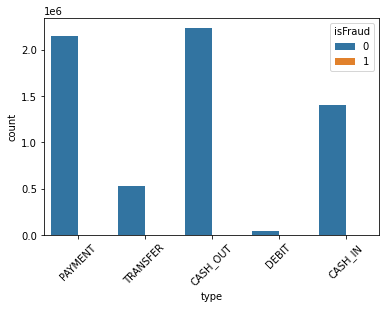

In [14]:
#Fraud by Transaction Type
sns.countplot(x ='type',hue='isFraud',data=df)
plt.xticks(rotation=45)
plt.show()

In [15]:
df = df.sample(
200000,
random_state=42
)

print(df.shape)

(200000, 11)


In [16]:
df= df.drop(['nameOrig','nameDest'],axis=1)

In [17]:
df = pd.get_dummies(df,columns=['type'],drop_first=True)
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
3737323,278,330218.42,20866.00,351084.42,452419.57,122201.15,0,0,False,False,False,False
264914,15,11647.08,30370.00,18722.92,0.00,0.00,0,0,False,False,True,False
85647,10,152264.21,106589.00,258853.21,201303.01,49038.80,0,0,False,False,False,False
5899326,403,1551760.63,0.00,0.00,3198359.45,4750120.08,0,0,False,False,False,True
2544263,206,78172.30,2921331.58,2999503.88,415821.90,337649.60,0,0,False,False,False,False


In [18]:
#Define X and y
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [19]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) 
#statify=y is v imp for imbalanced data

In [20]:
#SMOTE (balance training data)
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(
X_train,
y_train
)


isFraud
0    159786
1    159786
Name: count, dtype: int64

In [21]:
print(y_train_sm.value_counts())

isFraud
0    159786
1    159786
Name: count, dtype: int64


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [31]:
y_pred = rf.predict(X_test)

In [32]:
#confusion matrix
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[39946     0]
 [   13    41]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39946
           1       1.00      0.76      0.86        54

    accuracy                           1.00     40000
   macro avg       1.00      0.88      0.93     40000
weighted avg       1.00      1.00      1.00     40000



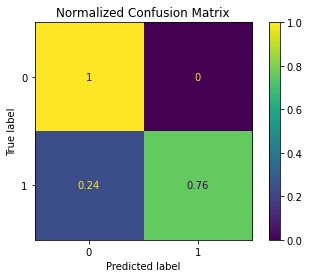

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
y_test,
y_pred,
normalize='true'
)

plt.title('Normalized Confusion Matrix')
plt.show()

In [40]:
importance = pd.Series(
rf.feature_importances_,
index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

oldbalanceOrg     0.284053
newbalanceOrig    0.165039
amount            0.145466
type_TRANSFER     0.095458
newbalanceDest    0.079594
step              0.072307
type_PAYMENT      0.059088
oldbalanceDest    0.052290
type_CASH_OUT     0.045177
isFlaggedFraud    0.001410
dtype: float64


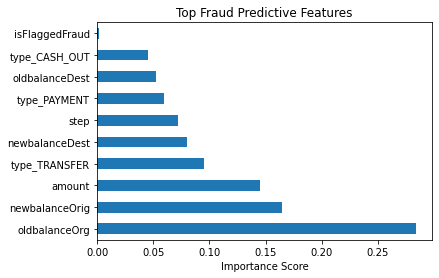

In [43]:
importance.head(10).plot(
kind='barh'
)

plt.title("Top Fraud Predictive Features")
plt.xlabel("Importance Score")
plt.show()

In [45]:
#export prediction results
results = X_test.copy()

results['Actual_Fraud'] = y_test.values
results['Predicted_Fraud'] = y_pred

results.to_csv(
'fraud_dashboard_data.csv',
index=False
)
print("Export complete")

Export complete
